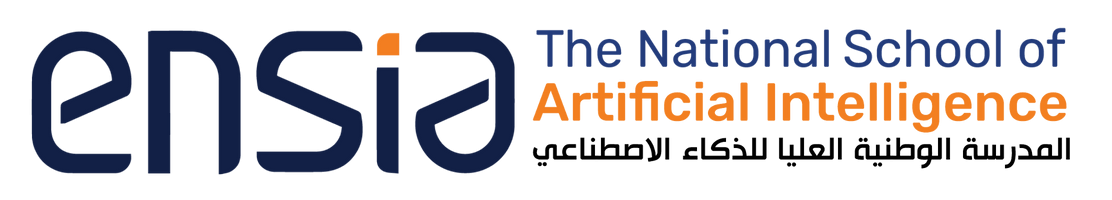

# **PROBABILITY BASED LEARNING___Part_II: HYBRID NAIVE BAYES and BAYESIAN NETWORK**

# **Overview**
> Probabilistic models are fundamental in machine learning for reasoning under uncertainty. In this lab, we will explore two powerful probabilistic approaches:

> - **Hybrid Naive Bayes** – A classifier that effectively handles both categorical and continuous features by integrating Gaussian Naive Bayes with Categorical Naive Bayes.

> - **Bayesian Networks** – A graphical model that represents dependencies between variables and enables probabilistic inference.

> Through hands-on implementation, you will gain insights into how these models work, how they differ, and how they can be leveraged for decision-making.


## **Objectives**
> By the end of this lab, you will:

> - ✅ Implement a Hybrid Naive Bayes classifier, combining Gaussian and Categorical Naive Bayes to handle mixed data types.
- ✅ Compare probability-space vs. log-space computations for numerical stability.
- ✅ Construct a Bayesian Network, define its Conditional Probability Tables (CPTs), and use it for probabilistic inference.
- ✅ Implement a CPTs calculation function that automatically determine CPTs given a Bayesian network and a Dataset.
- ✅ Understand the advantages and limitations of these probabilistic models in real-world scenarios.


---
# **PART I: Hybrid Naive Bayes**
---

>The Hybrid Naive Bayes (HNB) classifier extends the Naive Bayes algorithm to handle both categorical and continuous features. In the previous lab, we explored **binning** as a method to convert continuous features into categorical ones, allowing us to apply a Categorical Naive Bayes classifier. However, this approach can lead to **information loss** during discretization.

> An alternative approach is to combine **Categorical Naive Bayes** (for discrete attributes) and **Gaussian Naive Bayes** (for continuous attributes), enabling direct modeling of continuous features using probability density functions while preserving the naive **independence assumption**.

**HOW HYBRID NAIVE BAYES WORKS:**
HNB classifier calculates the probability of an event in the following steps:

  * **Step 1:** Calculate the probability of each class based on training data.
  * **Step 2:** For categorical features: Compute conditional probabilities using frequency-based estimates.
  * **Step 3:** For continuous features: Estimate likelihoods using the Gaussian probability density function (PDF).
  * **Step 4:** Combine prior and likelihood probabilities to compute posterior probabilities for each class.
  * **Step 5:** Assign the class with the highest posterior probability to the input.
  

Naive Bayes Classifier formula can be written based on Bayes theorem as:
## Formula  

The posterior probability of a class $(C_k)$ given a feature vector $( X = (x_1, x_2, \dots, x_n))$ is:

$P(C_k \mid X) = \frac{P(C_k) \prod_{x_i \in \text{cat}} P(x_i \mid C_k) \prod_{x_j \in \text{cont}} f(x_j \mid C_k)}{P(X)}$

where:

- $P(C_k)$ is the **prior probability** of class $C_k$.
- $P(x_i \mid C_k)$ is the **categorical likelihood**, estimated using frequency-based probabilities.
- $f(x_j \mid C_k)$ is the **probability density function (PDF)** for continuous features, typically modeled using a Gaussian distribution:


$f(x_j \mid C_k) = \frac{1}{\sqrt{2\pi\sigma_{jk}^2}} \exp\left(-\frac{(x_j - \mu_{jk})^2}{2\sigma_{jk}^2} \right)$

Where:

$\mu_{jk}$ and $\sigma_{jk}^2$ are the **mean and variance** of feature $x_j$ given class $C_k$.

- $P(X)$ is the **normalization factor**, ensuring that probabilities sum to 1, but it is usually ignored in classification since it does not affect relative comparisons between classes.
`


## **Implementation**

Before we jump into the main Naive bayes classes, let us first define some utility functions that we might need in some part of the upcoming sections

In [34]:
!pip install numpy pandas matplotlib scipy scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from math import sqrt
from math import exp
from math import pi

from scipy import stats

from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.model_selection import train_test_split

> ### Utility Functions

> `accuracy_score`

In [35]:
def accuracy_score(y_true, y_pred):

	"""	score = (y_true - y_pred) / len(y_true) """

	return round(float(sum(y_pred == y_true))/float(len(y_true)) * 100 ,2)

> `is_continuous`

In [36]:
def is_continuous(series, threshold=2):
    """
    Determines if a pandas Series should be considered continuous.

    Parameters:
        series (pd.Series): The column to check.
        threshold (int): The minimum number of unique values required for the series to be considered continuous.

    Returns:
        bool: True if the series is numeric and has more than `threshold` unique values, False otherwise.
    """
    if pd.api.types.is_numeric_dtype(series):
        # Count unique values, ignoring missing values
        unique_vals = series.dropna().unique()
        return len(unique_vals) > threshold
    return False

In [37]:
# Define a function to plot the distribution and fitted curves
def plot_distributions(dataset):
  # Plot the distribution for each feature
  for feature_name in dataset.columns:

    if feature_name != 'target' and is_continuous(dataset[feature_name]):  # Skip target variable if present
      # plot_distribution(feature_name, dataset)
      # Extract the feature data
      feature_data = dataset[feature_name]

      # Try fitting a normal distribution
      norm_params = stats.norm.fit(feature_data)
      norm_dist = stats.norm(*norm_params)

      # Try fitting an exponential distribution
      exp_params = stats.expon.fit(feature_data)
      exp_dist = stats.expon(*exp_params)

      # Generate bins for the histogram
      bins = plt.hist(feature_data, density=True)[1]

      # Plot the histogram
      plt.plot(bins, norm_dist.pdf(bins), label='Normal Distribution')
      plt.plot(bins, exp_dist.pdf(bins), label='Exponential Distribution')
      plt.hist(feature_data, density=True, alpha=0.3)  # Semi-transparent histogram

      # Set labels and title
      plt.xlabel(feature_name)
      plt.ylabel('Density')
      plt.title(f'Distribution of {feature_name}')
      plt.legend()
      plt.grid(True)
      plt.show()

> ### Loading the data

In [38]:
df = pd.read_csv('data/nb_data.csv')
y = df['Play']
X = df.drop(['Play'], axis = 1)
# X = df

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [40]:
trues = X_train[y == "yes"]
falses = X_train[y == "no"]

/tmp/ipykernel_37267/2474364609.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  trues = X_train[y == "yes"]
/tmp/ipykernel_37267/2474364609.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  falses = X_train[y == "no"]


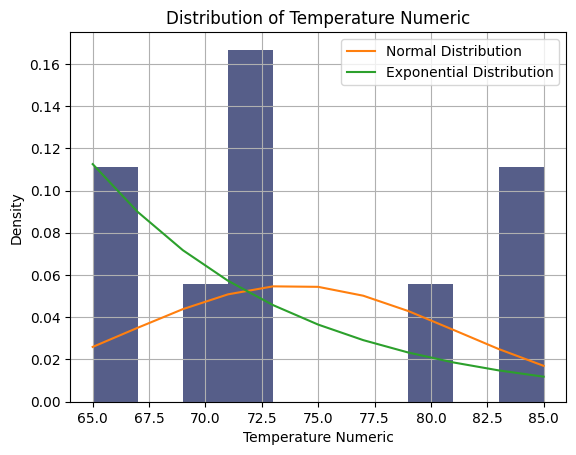

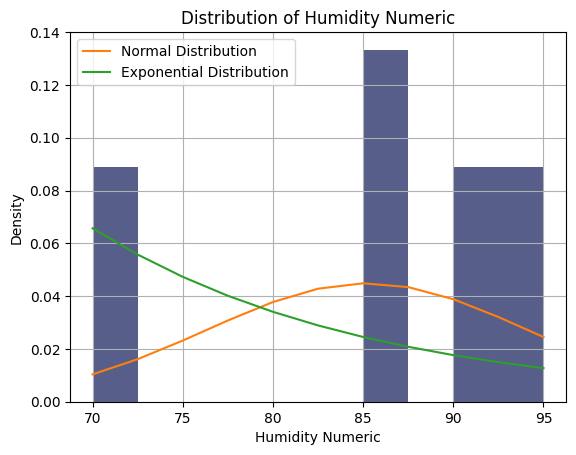

In [41]:
plot_distributions(falses)

> ## **Hybrid Naive Bayes Classifier Class**

In [42]:
class HybridNaiveBayesClassifier:
    def __init__(self, continuous_features=None, categorical_features=None, alpha = 0):
        """
        Parameters:
            continuous_features (list of str): Names of continuous features.
            categorical_features (list of str): Names of categorical features.
            alpha (float): smoothing factor.
        """
        self.continuous_features = continuous_features or []
        self.categorical_features = categorical_features or []
        self.classes = None
        self.priors = {}
        # For continuous features: store per-class means and stds (as numpy arrays)
        self.gaussian_likelihoods = {}
        # For categorical features: store per-class likelihoods as nested dictionaries
        self.categorical_likelihoods = {}
        self.alpha = alpha #Smoothing factor

    def fit(self, X: pd.DataFrame, y: np.ndarray):
        """
        Fit the hybrid classifier.
        Assumption: All features are encoded

        Parameters:
            X (pd.DataFrame): DataFrame containing features.
            y (np.ndarray): Array-like of class labels.
        """
        # Determine continuous and categorical features
        for col in X.columns:
          if is_continuous(X[col]):
            self.continuous_features.append(col)
          else:
            self.categorical_features.append(col)
        #-----------------------------------------------------------------------
        #-----------------------------Step 1------------------------------------
        #-----------------------------------------------------------------------
        self.classes, counts = np.unique(y, return_counts=True)  
        self.priors = dict(zip(self.classes, counts / len(y)))

        #-----------------------------------------------------------------------
        #-----------------------------Step 2 (Categorical)----------------------
        #-----------------------------------------------------------------------
        # **************Fit categorical likelihoods.************************
        self.categorical_likelihoods = {}
        for class_ in self.classes:
            self.categorical_likelihoods[class_] = {}
            X_cat = X.loc[y == class_, self.categorical_features]
            total = len(X_cat)
            for attr in self.categorical_features:
                # Count the frequency of each categorical value.
                values, counts = np.unique(X_cat[attr], return_counts=True)

                domain_size = len(np.unique(X[attr])) 
                smoothed_prob = (counts + self.alpha) / (total + self.alpha * domain_size)

                self.categorical_likelihoods[class_][attr] = dict(zip(values, smoothed_prob))

        #-----------------------------------------------------------------------
        #-----------------------------Step 3 (Gaussian)-------------------------
        #-----------------------------------------------------------------------
        # **********Fit Gaussian likelihoods for continuous features.***********
        self.gaussian_likelihoods = {}
        for class_ in self.classes:
            self.gaussian_likelihoods[class_] = {}
            X_cont = X.loc[y == class_, self.continuous_features]  

            means = X_cont.mean()

            stds = X_cont.std()

            # Store in dictionary.
            self.gaussian_likelihoods[class_]['means'] = means
            self.gaussian_likelihoods[class_]['stds'] = stds

    def predict(self, X: pd.DataFrame):
        """
        Predict class labels for X.

        Parameters:
            X (pd.DataFrame): DataFrame containing features.

        Returns:
            np.ndarray: Array of predicted class labels.
        """
        predictions = []
        for _, row in X.iterrows():
            predictions.append(self.__predict(row))
        return np.array(predictions)

    def __predict(self, x):
        """
        Predict class for a single data point (x is a pandas Series).
        """
        class_probabilities = {}
        for class_ in self.classes:
            # Start with the class prior.
            prob = self.priors[class_]
            #-------------------------------------------------------------------
            #-----------------------------Step 4 (Gaussian)---------------------
            #-------------------------------------------------------------------
            if self.continuous_features: # TODO: Set the appropriate condition
                x_cont = x[self.continuous_features].to_numpy(dtype=float)
                means = self.gaussian_likelihoods[class_]['means']

                stds = self.gaussian_likelihoods[class_]['stds']

                cont_probs = self.__gaussian_fn(x_cont, means, stds)

                # Multiply in the continuous (Gaussian) likelihood.
                prob *= np.prod(cont_probs)

            #-------------------------------------------------------------------
            #-----------------------------Step 4 (Categorical)------------------
            #-------------------------------------------------------------------
            if self.categorical_features: # TODO: Set the appropriate condition
                for attr in self.categorical_features:
                    value = x[attr]

                    attr_prob = self.categorical_likelihoods[class_][attr].get(value, 0)  # TODO: Get value likelihood (consider using .get())

                    # Multiply in the categorical likelihood.
                    prob *= attr_prob

            class_probabilities[class_] = prob

        #-----------------------------------------------------------------------
        #----------------------------- Step 5 ----------------------------------
        #-----------------------------------------------------------------------
        # Return the class with the highest probability.
        return max(class_probabilities.items(), key=lambda item: item[1])[0]

    def __gaussian_fn(self, x, means, stds):
      # Convert inputs to numpy arrays and assert matching shapes
      x = np.array(x, dtype=float)
      means = np.array(means, dtype=float)
      stds = np.array(stds, dtype=float)
      assert x.shape == means.shape == stds.shape, "x, means, and stds must have the same shape."

      return (1 / (stds * np.sqrt(2 * np.pi))) * np.exp(-0.5 * (x - means) ** 2 / (stds ** 2))

In [43]:
# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Test with Mixed dataset----------------------------------------------
#-----------------------------------------------------------------------------------------------------------
clf = HybridNaiveBayesClassifier(alpha=1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy Score: ", accuracy_score(y_test, y_pred) )
# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Test with Categorical dataset----------------------------------------
#-----------------------------------------------------------------------------------------------------------
#Load and preprocess the data
y = df['Play']
X = df.drop(['Play',  'Temperature Numeric' , 'Humidity Numeric' ], axis = 1)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

clf2 = HybridNaiveBayesClassifier(alpha=1)
clf2.fit(X_tr, y_tr)
y_pred2 = clf2.predict(X_te)
print("Accuracy Score for categorical test: ", accuracy_score(y_te, y_pred2) )

# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Test with Continuous dataset----------------------------------------
#-----------------------------------------------------------------------------------------------------------
# Initialize and fit the hybrid classifier.
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

X_tr3, X_te3, y_tr3, y_te3 = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

clf3 = HybridNaiveBayesClassifier(alpha=1)
clf3.fit(X_tr3, y_tr3)
y_pred3 = clf3.predict(X_te3)
print("Accuracy Score for Continuous test: ", accuracy_score(y_pred3, y_te3) )

Accuracy Score:  66.67
Accuracy Score for categorical test:  88.89
Accuracy Score for Continuous test:  97.78


### 🛠️ **Extra Task**: *Computing Probabilities in Log Space*

> In this task, you will compute probabilities in **log space** instead of standard probability values.

> **Why use log space?**

> Probabilities are often very small, and multiplying them directly can lead to numerical underflow. By using log probabilities, multiplication turns into **addition**, which is numerically more **stable**:

> $P(A, B) = P(A)\text{ x } P(B)  ⇒ log \text{ } P(A, B) = log \text{ } P(A) + log \text{ } P(B) $

- **Adjust the Hybrid NB Classifier to use log probabilities instead of standard probabilities**
- **Explain why working in log space helps when dealing with very small probabilities.**

In [44]:
# we use log space for better numerical stability when multiplying small probabilities, but here we are directly multiplying probabilities which can lead to underflow issues. In practice, you might want to implement the log version of the Naive Bayes classifier for better performance on larger datasets or datasets with many features.

class LogHybridNaiveBayesClassifier(HybridNaiveBayesClassifier):
    def __predict(self, x):
        """
        Predict class for a single data point (x is a pandas Series) using log probabilities.
        """
        class_log_probabilities = {}
        for class_ in self.classes:
            # Start with the log of the class prior.
            log_prob = np.log(self.priors[class_])
            #-------------------------------------------------------------------
            #-----------------------------Step 4 (Gaussian)---------------------
            #-------------------------------------------------------------------
            if self.continuous_features:
                x_cont = x[self.continuous_features].to_numpy(dtype=float)
                means = self.gaussian_likelihoods[class_]['means']
                stds = self.gaussian_likelihoods[class_]['stds']
                cont_probs = self.__gaussian_fn(x_cont, means, stds)

                # Add the log of the continuous (Gaussian) likelihood.
                log_prob += np.sum(np.log(cont_probs))

            #-------------------------------------------------------------------
            #-----------------------------Step 4 (Categorical)------------------
            #-------------------------------------------------------------------
            if self.categorical_features:
                for attr in self.categorical_features:
                    value = x[attr]
                    attr_prob = self.categorical_likelihoods[class_][attr].get(value, 1e-10)  # Use a small value to avoid log(0)
                    log_prob += np.log(attr_prob)

            class_log_probabilities[class_] = log_prob

        # Return the class with the highest log probability.
        return max(class_log_probabilities.items(), key=lambda item: item[1])[0]

In [45]:
# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Test with Mixed dataset----------------------------------------------
#-----------------------------------------------------------------------------------------------------------
clf = LogHybridNaiveBayesClassifier(alpha=1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy Score: ", accuracy_score(y_test, y_pred) )
# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Test with Categorical dataset----------------------------------------
#-----------------------------------------------------------------------------------------------------------
#Load and preprocess the data
y = df['Play']
X = df.drop(['Play',  'Temperature Numeric' , 'Humidity Numeric' ], axis = 1)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

clf2 = LogHybridNaiveBayesClassifier(alpha=1)
clf2.fit(X_tr, y_tr)
y_pred2 = clf2.predict(X_te)
print("Accuracy Score for categorical test: ", accuracy_score(y_te, y_pred2) )

# ----------------------------------------------------------------------------------------------------------
# -------------------------------------Test with Continuous dataset----------------------------------------
#-----------------------------------------------------------------------------------------------------------
# Initialize and fit the hybrid classifier.
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

X_tr3, X_te3, y_tr3, y_te3 = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

clf3 = LogHybridNaiveBayesClassifier(alpha=1)
clf3.fit(X_tr3, y_tr3)
y_pred3 = clf3.predict(X_te3)
print("Accuracy Score for Continuous test: ", accuracy_score(y_pred3, y_te3) )

Accuracy Score:  66.67
Accuracy Score for categorical test:  88.89
Accuracy Score for Continuous test:  97.78


---
# **PART 2: Bayesian Networks**
---


> A Bayesian network is a directed acyclical graph (there are no cycles in the graph) that is composed of three basic elements:
- ***nodes***: each feature in a domain is represented by a single node in the graph.
- ***edges***: nodes are connected by directed links; the connectivity of the links in a graph encodes the influence and conditional independence relationships between nodes.
- ***conditional probability tables (CPT)***: each node has a conditional probability table (***CPT***) associated with it. ***CPT*** lists the probability distribution of the feature represented by the node conditioned on the features represented by the other nodes to which a node is connected by edges.

> For a network describing a domain consisting of two features **A** and **B**. The ***directed link from A to B*** indicates that the value of ***A directly influences*** the value of*** B***.

>In probability terms, *the directed edge from A to B* :

>$P(A,B) = P(B/A) * P(A)$

>* node **A** is a ***parent*** node of **B**
* node **B** is a ***child*** node of **A**
* The **CPT** associated with each node defines the *probabilities* of each feature taking a value given the value(s) of its parent node(s)
* Node A has no parents, so the CPT just lists the ***unconditional probability*** distribution for A.

## Overview

>In this section, we will explore **Bayesian Networks** models that represent probabilistic relationships between variables. We will cover:

>- **Model Construction:** Creating a Bayesian Network with nodes and directed edges.
- **Defining CPTs:** Manually specifying Conditional Probability Tables (CPTs) for each node.
- **Visualization:** Plotting the network to see variable dependencies.
- **Automated CPT Calculation:** Using a function to automatically calculate CPTs from data.
- **Inference:** Making predictions using the Bayesian Network.

>Let's get started!

## Prerequisites and imports

 > We will be using pgmpy library to build and manupilate our network, while networkx will be used for visualizing our models.

In [46]:
!pip install pgmpy

In [47]:
! pip install networkx

In [48]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# pgmpy modules for Bayesian Networks
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

## Utility Functions



In [49]:
def visualize(model):
  # Visualize the network using networkx
  graph = nx.DiGraph()
  for node in model.nodes:
      graph.add_node(node)
  for parent, child in model.edges:
      graph.add_edge(parent, child)

  nx.draw(
      graph,
      with_labels=True,
      node_size=2000,
      node_color="skyblue",
      node_shape="o",
      alpha=0.7,
      linewidths=5
  )
  plt.title("Simple Bayesian Network")
  plt.show()

## Simple Bayesian Network Example

>We start with an example Bayesian Network with 3 nodes:

>- **accident**
- **rain**
- **traffic_jam**

>The **traffic_jam** node depends on both **accident** and **rain**.

>We will:
1. Build the network structure.
2. Visualize the network.
3. Define and add CPTs.
4. Perform inference.

Nodes: ['accident', 'rain', 'traffic_jam']
Edges: [('accident', 'traffic_jam'), ('rain', 'traffic_jam')]


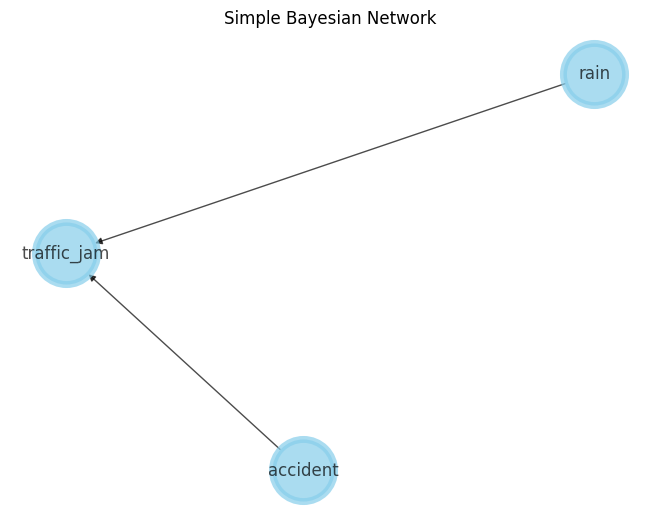

In [50]:
# Create the model
model = DiscreteBayesianNetwork()
model.add_nodes_from(["accident", "rain", "traffic_jam"])
model.add_edge("rain", "traffic_jam")
model.add_edge("accident", "traffic_jam")

print("Nodes:", model.nodes())
print("Edges:", model.edges())

visualize(model)

### Defining CPTs

>Next, we define the CPTs for each node.

>- **rain** and **accident** have no parents, so their CPTs are simply their marginal probabilities.
- **traffic_jam** depends on **rain** and **accident**, so its CPT is defined conditionally.

>The CPTs are defined using `TabularCPD` from pgmpy.

In [51]:
# Define CPT for rain
cpd_rain = TabularCPD("rain", variable_card=2, values=[[0.4], [0.6]])

# Define CPT for accident
cpd_accident = TabularCPD("accident", variable_card=2, values=[[0.1], [0.9]])

# Define CPT for traffic_jam (with evidence: rain and accident)
cpd_traffic_jam = TabularCPD(
    "traffic_jam",
    variable_card=2,
    values=[
        [0.9, 0.6, 0.7, 0.1],  # P(traffic_jam=False)
        [0.1, 0.4, 0.3, 0.9]   # P(traffic_jam=True)
    ],
    evidence=["rain", "accident"],
    evidence_card=[2, 2]
)

# Add the CPTs to the model
model.add_cpds(cpd_rain, cpd_accident, cpd_traffic_jam)
print("Model CPTs:")
for cpd in model.get_cpds():
    print(cpd)

# Validate the model
print("Is the model valid?", model.check_model())

Model CPTs:
+---------+-----+
| rain(0) | 0.4 |
+---------+-----+
| rain(1) | 0.6 |
+---------+-----+
+-------------+-----+
| accident(0) | 0.1 |
+-------------+-----+
| accident(1) | 0.9 |
+-------------+-----+
+----------------+-------------+-------------+-------------+-------------+
| rain           | rain(0)     | rain(0)     | rain(1)     | rain(1)     |
+----------------+-------------+-------------+-------------+-------------+
| accident       | accident(0) | accident(1) | accident(0) | accident(1) |
+----------------+-------------+-------------+-------------+-------------+
| traffic_jam(0) | 0.9         | 0.6         | 0.7         | 0.1         |
+----------------+-------------+-------------+-------------+-------------+
| traffic_jam(1) | 0.1         | 0.4         | 0.3         | 0.9         |
+----------------+-------------+-------------+-------------+-------------+
Is the model valid? True


### Inference with the Bayesian Network

>Once the Bayesian Network is built and CPTs are defined, we can perform inference.

>For example, we can query the probability distribution of **traffic_jam** given that `rain=1` and `accident=1`.

>In Bayesian Networks, the probability of a target given evidence is computed as:

>$M(q) = \arg\max_{t \in \text{levels}(t)} P(t \mid q)$
  
>Where:
- **$M(q)$** is the prediction for the query.
- **$P(t \mid q)$** is the probability computed by the network for the event (t = l) given the evidence (q).

>One major advantage is that Bayesian Networks can handle missing evidence elegantly.

> **Query:** What is the probability of `traffic_jam` given `rain` = *True* and `accident` = *True* ?

In [52]:
# Perform inference using VariableElimination
inference = VariableElimination(model)

q = inference.query(variables=["traffic_jam"], evidence={"rain": 1, "accident": 1})
print("Inference Result for traffic_jam given rain=1 and accident=1:")
print(q)

Inference Result for traffic_jam given rain=1 and accident=1:
+----------------+--------------------+
| traffic_jam    |   phi(traffic_jam) |
+================+====================+
| traffic_jam(0) |             0.1000 |
+----------------+--------------------+
| traffic_jam(1) |             0.9000 |
+----------------+--------------------+


## **Automating CPTs Calculation**

>Manually defining CPTs for every node can be tedious. The following function, `calculate_cpds()`, automates the process by:
- **Step 1:** Reading the network structure.
- **Step 2:** Computing the marginal probabilities for nodes without parents.
- **Step 3:** Grouping the data by evidence for nodes with parents.
- **Step 4:** Calculating liklihoods and applying Laplace smoothing.
- **Step 5:** Creating and attaching the appropriate CPDs to the network.

> ***Note:*** For **Step 4**, remember that likelihoods are calculated based on all parent nodes for each node (using the grouped data in **step 3**).

>This automation ensures consistency and efficiency when building data-driven Bayesian Networks.

In [53]:
def calculate_cpds(model: BayesianNetwork, df: pd.DataFrame, smoothing: float = 1):
    """
    Calculate and attach Conditional Probability Tables (CPDs) for every node in the
    Bayesian network using data from df.

    Parameters:
        model (BayesianNetwork): The Bayesian network structure with nodes and edges.
        df (pd.DataFrame): The dataset used to estimate probabilities.
        smoothing (float): Laplace smoothing factor.

    Returns:
        BayesianNetwork: The model with CPDs attached.
    """
    for node in model.nodes():
        #------------------------------------------------------------------------------------------------------------------------------
        #--------------Step 1----------------------------------------------------------------------------------------------------------
        #------------------------------------------------------------------------------------------------------------------------------
        parents = model.get_parents(node)

        domain = sorted(df[node].unique())# TODO: Determine the domain (sorted unique values) for the node.

        node_card = len(domain)# TODO: Get the number of nodes' uniques values

        #------------------------------------------------------------------------------------------------------------------------------
        #--------------Step 2----------------------------------------------------------------------------------------------------------
        #------------------------------------------------------------------------------------------------------------------------------
        if not parents:
            # Marginal CPD: count occurrences and apply smoothing.
            values, counts = np.unique(df[node], return_counts=True)

            total = len(df)

            numerator = counts + smoothing

            denominator = total + smoothing * node_card

            cpd_values = numerator / denominator
            # Ensure values are a column vector of shape (variable_card, 1)
            cpd_values = np.array([[v] for v in cpd_values.tolist()])

            cpd = TabularCPD(node, node_card, cpd_values) # TODO: Create a TabularCPD object
        else:
            #------------------------------------------------------------------------------------------------------------------------------
            #--------------Step 3----------------------------------------------------------------------------------------------------------
            #------------------------------------------------------------------------------------------------------------------------------
            evidence = parents
            # Map each evidence with its unique values
            evidence_values = {ev: sorted(df[ev].unique()) for ev in evidence} # TODO: fill with evidence nodes and their unique values ({ev1: (val1, val2), ev2....})

            # Generate all combinations of evidence values
              # Ex: all_combinations = [('no', 'low'), ('no', 'high'), ('yes', 'low'), ('yes', 'high')]
            all_combinations = list(pd.MultiIndex.from_product([evidence_values[ev] for ev in evidence]))

            # Compute the smoothed probability for each evidence combination
            cpd_dict = {}
            for comb in all_combinations:# TODO: Loop through all_combinations

                # Build a mask for the current evidence combination
                # 1. Start with a mask that is True for all rows in the DataFrame df.
                mask = np.ones(len(df), dtype=bool)

                # 2. Iterate over each evidence variable (ev) and its corresponding value (val) from the current combination.
                for ev, val in zip(evidence, comb):# TODO: Fill in the gap

                    # 3. Update the mask using the logical AND operator (&=)
                    #    to keep only the rows where df[ev] matches val.
                    mask &= (df[ev] == val)# TODO: Keep only the rows where df[ev] matches val

                # 4. Compute the total number of rows that satisfy the current evidence combination,
                #    which corresponds to the number of True values in the mask.
                total = mask.sum()# TODO: Get the total number of True values in the mask

                probs = []
                for val in domain:
                    #------------------------------------------------------------------------------------------------------------------------------
                    #--------------Step 4----------------------------------------------------------------------------------------------------------
                    #------------------------------------------------------------------------------------------------------------------------------
                    # Count the number of rows where the node takes the current value
                    # while also satisfying the given evidence combination.
                    count = ((df[node] == val) & mask).sum()# TODO: Fill in the gap

                    # Apply Laplace smoothing to avoid zero probabilities.
                    prob = (count + smoothing) / (total + smoothing * node_card)#TODO: Apply likelihood formula with Laplace smoothing

                    # Store the computed probability for this node value.
                    probs.append(prob)

                # Store the computed probabilities for this evidence combination in the CPD dictionary.
                cpd_dict[comb] = probs
            #------------------------------------------------------------------------------------------------------------------------------
            #--------------Step 5----------------------------------------------------------------------------------------------------------
            #------------------------------------------------------------------------------------------------------------------------------
            # Build the CPD matrix: rows correspond to each value in 'domain' (target),
            # columns correspond to each evidence combination.
            cpd_values = np.array([[cpd_dict[comb][i] for comb in all_combinations] for i in range(len(domain))])# TODO: Fill in the gap

            # Determine the cardinality for each evidence variable
            evidence_card = [len(evidence_values[ev]) for ev in evidence]# TODO : Fill in the gap

            cpd = TabularCPD(variable=node, variable_card=node_card, values=cpd_values, evidence=evidence, evidence_card=evidence_card)# TODO: Create the TabularCPD object

        model.add_cpds(cpd)#TODO : Add the calculated cpd for node to the network

    print("Model CPTs:")
    for cpd in model.get_cpds():
      print(cpd)

    assert model.check_model(), "The Bayesian network with CPDs is not valid."
    return model

### Testing our automated function

> Now that our CPTs function is ready, let us try it on the *House Alarm* dataset.

#### Loading the data

In [54]:
df_alarm = pd.read_csv("data/House_Alarm.csv")
df_alarm

,Storm,Burglar,Cat,Alarm
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,True
5,False,False,True,False
6,False,True,False,False
7,False,True,False,True
8,False,True,True,True
9,True,False,True,True


#### Build and visualize the model (Bayesian Network)

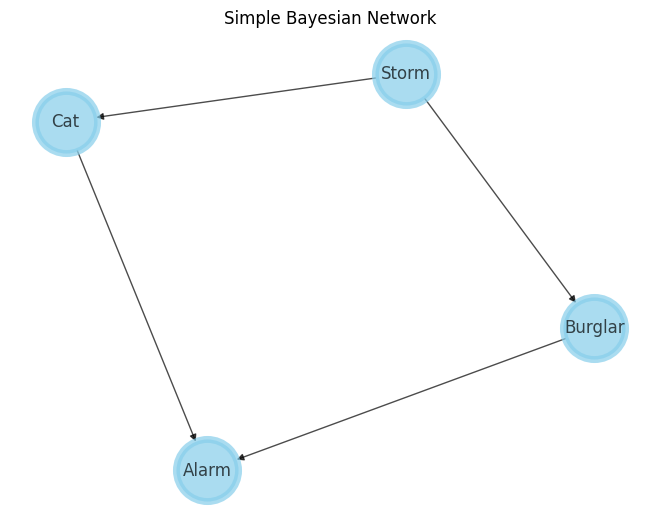

In [55]:
# Create the modeel : model_3
model_3 = DiscreteBayesianNetwork( )#TODO: Create bayesian network object

## Create the arcs :
model_3.add_edge("Storm", "Burglar")#TODO : create and edge between "Storm" and "Burglar"
model_3.add_edge("Storm", "Cat")#TODO : create and edge between "Storm" and "Cat"
model_3.add_edge("Burglar", "Alarm")#TODO : create and edge between "Burglar" and "Alarm"
model_3.add_edge("Cat", "Alarm")#TODO : create and edge between "Cat" and "Alarm"

visualize(model_3)

#### Calculate CPTs

> Now we can calculate and create all CPTs in single line of code, isn't that cool! 😎

In [56]:
model_3 = calculate_cpds(model_3, df_alarm)
print("Automated CPDs added to the model.")

Model CPTs:
+----------+----------+
| Storm(0) | 0.666667 |
+----------+----------+
| Storm(1) | 0.333333 |
+----------+----------+
+------------+---------------------+--------------------+
| Storm      | Storm(0)            | Storm(1)           |
+------------+---------------------+--------------------+
| Burglar(0) | 0.6363636363636364  | 0.6666666666666666 |
+------------+---------------------+--------------------+
| Burglar(1) | 0.36363636363636365 | 0.3333333333333333 |
+------------+---------------------+--------------------+
+--------+--------------------+--------------------+
| Storm  | Storm(0)           | Storm(1)           |
+--------+--------------------+--------------------+
| Cat(0) | 0.7272727272727273 | 0.3333333333333333 |
+--------+--------------------+--------------------+
| Cat(1) | 0.2727272727272727 | 0.6666666666666666 |
+--------+--------------------+--------------------+
+----------+--------------------+-----+------------+--------------------+
| Burglar  | Burg

> ***Note:*** Please review the hidden cell below (click on this emogi 🔶) that demonstrates how the Conditional Probability Tables (CPTs) are manually calculated using logical masks and Laplace smoothing. Consider this approach alongside automated methods—what do you think are the advantages and disadvantages of each? 🤔

<details>
<summary><b> 🔶 House Alarm Bayesian Network Using Manual CPTs calculation</b></summary>

```python
# --- Bayesian Network Construction for House Alarm Dataset ---

# Create the Bayesian Network model (model_4)
model_4 = BayesianNetwork()
model_4.add_edge("Storm", "Burglar")
model_4.add_edge("Storm", "Cat")
model_4.add_edge("Burglar", "Alarm")
model_4.add_edge("Cat", "Alarm")

print("Model Edges:", model_4.edges())

# --- Calculating Conditional Probabilities from Data ---

# Total number of samples in the dataset
total_samples = len(df)

# Calculate the marginal probability for Storm=True
p_storm_true = df['Storm'].value_counts()[True] / total_samples

# Calculate conditional probabilities for Burglar given Storm
p_burglar_given_storm_true = df[(df['Storm'] == True) & (df['Burglar'] == True)].shape[0] / df[df['Storm'] == True].shape[0]
p_burglar_given_storm_False = df[(df['Storm'] == False) & (df['Burglar'] == True)].shape[0] / df[df['Storm'] == False].shape[0]

# Calculate conditional probabilities for Cat given Storm
p_cat_given_storm_true = df[(df['Storm'] == True) & (df['Cat'] == True)].shape[0] / df[df['Storm'] == True].shape[0]
p_cat_given_storm_False = df[(df['Storm'] == False) & (df['Cat'] == True)].shape[0] / df[df['Storm'] == False].shape[0]

# Calculate conditional probabilities for Alarm given Burglar and Cat
p_alarm_given_burglar_cat = df[(df['Burglar'] == True) & (df['Cat'] == True) & (df['Alarm'] == True)].shape[0] / df[(df['Burglar'] == True) & (df['Cat'] == True)].shape[0]
p_alarm_given_burglar_Ncat = df[(df['Burglar'] == True) & (df['Cat'] == False) & (df['Alarm'] == True)].shape[0] / df[(df['Burglar'] == True) & (df['Cat'] == False)].shape[0]
p_alarm_given_Nburglar_cat = df[(df['Burglar'] == False) & (df['Cat'] == True) & (df['Alarm'] == True)].shape[0] / df[(df['Burglar'] == False) & (df['Cat'] == True)].shape[0]
p_alarm_given_Nburglar_Ncat = df[(df['Burglar'] == False) & (df['Cat'] == False) & (df['Alarm'] == True)].shape[0] / df[(df['Burglar'] == False) & (df['Cat'] == False)].shape[0]

# Print key probabilities for verification
print(f"P(Storm=True) = {p_storm_true:.4f}")
print(f"P(Burglar=True | Storm=True) = {p_burglar_given_storm_true:.2f}")
print(f"P(Cat=True | Storm=True) = {p_cat_given_storm_true:.2f}")
print(f"P(Alarm=True | Burglar=True, Cat=True) = {p_alarm_given_burglar_cat:.2f}")

# --- Defining the Conditional Probability Tables (CPTs) ---
from pgmpy.factors.discrete import TabularCPD

# CPT for Storm (marginal probability)
cpt_storm = TabularCPD(variable='Storm', variable_card=2, values=[[1 - p_storm_true], [p_storm_true]])
print("CPT for Storm:")
print(cpt_storm)

# CPT for Burglar given Storm
cpt_burglar = TabularCPD(
    variable='Burglar',
    variable_card=2,
    values=[
        [1 - p_burglar_given_storm_False, 1 - p_burglar_given_storm_true],
        [p_burglar_given_storm_False,     p_burglar_given_storm_true]
    ],
    evidence=['Storm'],
    evidence_card=[2]
)
print("CPT for Burglar:")
print(cpt_burglar)

# CPT for Cat given Storm
cpt_cat = TabularCPD(
    variable='Cat',
    variable_card=2,
    values=[
        [1 - p_cat_given_storm_False, 1 - p_cat_given_storm_true],
        [p_cat_given_storm_False,     p_cat_given_storm_true]
    ],
    evidence=['Storm'],
    evidence_card=[2]
)
print("CPT for Cat:")
print(cpt_cat)

# CPT for Alarm given Burglar and Cat
cpt_alarm = TabularCPD(
    variable='Alarm',
    variable_card=2,
    values=[
        [1 - p_alarm_given_Nburglar_Ncat, 1 - p_alarm_given_Nburglar_cat, 1 - p_alarm_given_burglar_Ncat, 1 - p_alarm_given_burglar_cat],
        [p_alarm_given_Nburglar_Ncat,     p_alarm_given_Nburglar_cat,     p_alarm_given_burglar_Ncat,     p_alarm_given_burglar_cat]
    ],
    evidence=['Burglar', 'Cat'],
    evidence_card=[2, 2]
)
print("CPT for Alarm:")
print(cpt_alarm)

# Add the CPTs to the model
model_4.add_cpds(cpt_storm, cpt_burglar, cpt_cat, cpt_alarm)

# Check if the model is valid
print("Model is valid:", model_4.check_model())

```
</details>


## **Inference**

> Using the Variable Elimination inference method, perform the following queries on the Bayesian Network:

> - **Query 1:** Compute the probability distribution for the target variable **Alarm** given that both **Burglar** and **Cat** are *True*. This simulates the scenario where an alarm might be triggered by both a burglary and the presence of a cat.
> - **Query 2:** Compute the probability distribution for **Alarm** given that **Storm** is *True*, without any information about **Burglar** or **Cat**. This will help you observe how the network handles incomplete evidence.

In [58]:
# --- Inference using the Bayesian Network ---
from pgmpy.inference import VariableElimination
inference = VariableElimination(model_3)  # TODO: create a variable elimination object for model3

q_1 = inference.query(variables=['Alarm'], evidence={'Burglar': 1, 'Cat': 1})  # TODO: Predict Alarm given Burglar=True and Cat=True
print("Inference Result (Alarm | Burglar=True, Cat=True):")
print(q_1)

q_2 = inference.query(variables=['Alarm'], evidence={'Storm': 1})  # TODO: Predict Alarm given Storm=True
print("Inference Result (Alarm | Storm=True):")
print(q_2)

Inference Result (Alarm | Burglar=True, Cat=True):
+----------+--------------+
| Alarm    |   phi(Alarm) |
+==========+==============+
| Alarm(0) |       0.3333 |
+----------+--------------+
| Alarm(1) |       0.6667 |
+----------+--------------+
Inference Result (Alarm | Storm=True):
+----------+--------------+
| Alarm    |   phi(Alarm) |
+==========+==============+
| Alarm(0) |       0.5735 |
+----------+--------------+
| Alarm(1) |       0.4265 |
+----------+--------------+


> Demonstrate how changes in the probability distribution for the **Alarm** node **propagate** through the network and affect the **beliefs** (marginal probabilities) of its **parent** nodes (Burglar and Cat).

> - **Query 3:** First, compute the probability distribution for Alarm given evidence (e.g., Burglar=True and Cat=True).
- **Query 4:** Then, query the marginal probabilities for Burglar and Cat under different evidence scenarios for Alarm (e.g., when Alarm is high versus low).

> Observe how adjustments in the inferred probability for Alarm lead to corresponding changes in the beliefs about Burglar and Cat (parents). This illustrates the key Bayesian property of belief **propagation**, where evidence on one node influences the entire network.

In [59]:
from pgmpy.inference import VariableElimination

inference = VariableElimination(model_3)  # TODO: Create the inference object (VariableElimination)

# --- Query for parents given Alarm is True ---
q_burglar_alarm_true = inference.query(variables=['Burglar'], evidence={'Alarm': 1})  # TODO: Query Burglar given alarm is True
q_cat_alarm_true = inference.query(variables=['Cat'], evidence={'Alarm': 1})  # TODO: Query Cat given alarm is True

print("Marginal probabilities given Alarm = True:")
print("Burglar:")
print(q_burglar_alarm_true)
print("Cat:")
print(q_cat_alarm_true)

# --- Query for parents given Alarm is False ---
q_burglar_alarm_false = inference.query(variables=['Burglar'], evidence={'Alarm': 0})  # TODO: Query Burglar given alarm is False
q_cat_alarm_false = inference.query(variables=['Cat'], evidence={'Alarm': 0})  # TODO: Query Cat given alarm is False

print("\nMarginal probabilities given Alarm = False:")
print("Burglar:")
print(q_burglar_alarm_false)
print("Cat:")
print(q_cat_alarm_false)

Marginal probabilities given Alarm = True:
Burglar:
+------------+----------------+
| Burglar    |   phi(Burglar) |
+============+================+
| Burglar(0) |         0.4711 |
+------------+----------------+
| Burglar(1) |         0.5289 |
+------------+----------------+
Cat:
+--------+------------+
| Cat    |   phi(Cat) |
+========+============+
| Cat(0) |     0.5668 |
+--------+------------+
| Cat(1) |     0.4332 |
+--------+------------+

Marginal probabilities given Alarm = False:
Burglar:
+------------+----------------+
| Burglar    |   phi(Burglar) |
+============+================+
| Burglar(0) |         0.7728 |
+------------+----------------+
| Burglar(1) |         0.2272 |
+------------+----------------+
Cat:
+--------+------------+
| Cat    |   phi(Cat) |
+========+============+
| Cat(0) |     0.6170 |
+--------+------------+
| Cat(1) |     0.3830 |
+--------+------------+


---
# **Part 3: Visualizing and Analyzing Bayesian Networks with Bayes Server Online**
---

###Objectives:

* Learn how to create and visualize a BN in Bayes Server.
* Perform probabilistic inference using the software.
* Analyze the impact of evidence on a BN.

This example explores a Bayesian Network where an alarm may ring due to an earthquake or a burglary. Two people, John and Mary, may call if they hear the alarm.

### Network Structure
* Burglary (B) → (affects) Alarm (A)
* Earthquake (E) → (affects) Alarm (A)
* Alarm (A) → (affects) John Calls (J)
* Alarm (A) → (affects) Mary Calls (M)

**Given probabilites:** \

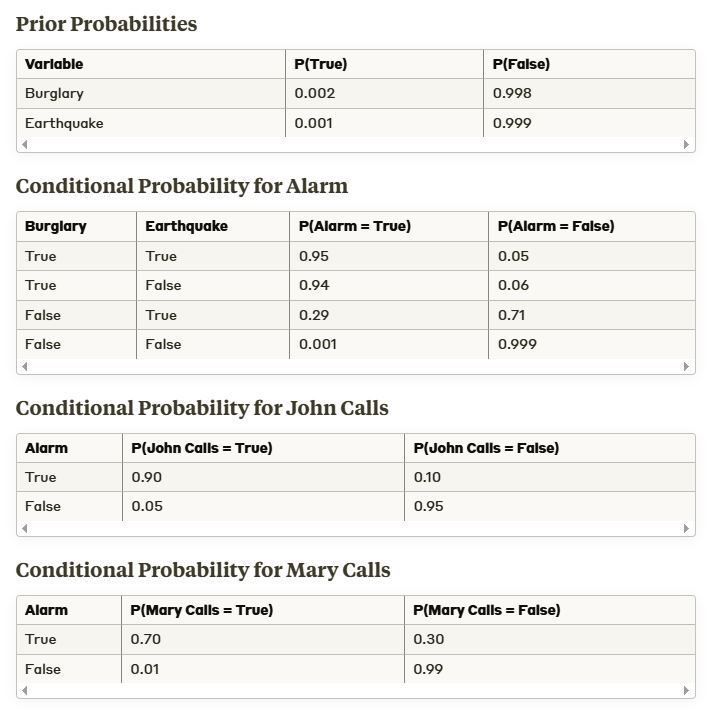


### Accessing Bayes Server:
1- Open [Bayes Server Online](https://) in your browser \
2- Create a New Bayesian Network (File -> New)

##Building the Bayesian Network in Bayes Server
1 - **Create Nodes:** Build -> Node -> Discrete \
2 - **Add Connection:** Build -> link -> Add Link(s) \
3 - **Define Conditional Probability Tables (CPTs)**: Build -> Distributions -> Edit Distributions \

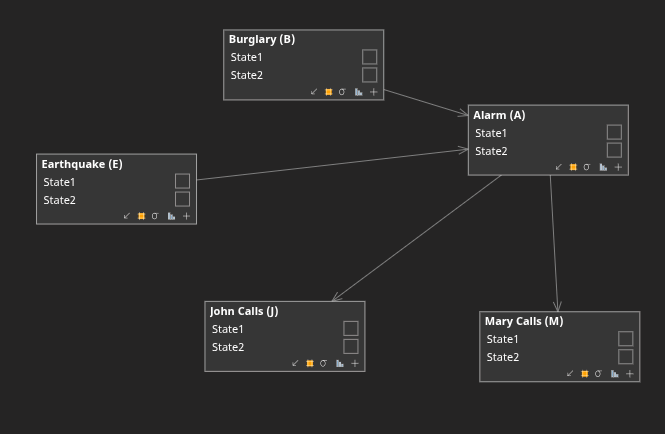